# Take-home assignment - 2

Problem Statement:

This notebook contains an implementation of an OCR model on Python (Caffe). It is a modification of the [CRNN](https://arxiv.org/pdf/1507.05717) architecture.


The following 3 tasks have to be worked on using this trained model:


1. Ensure the OCR output does not have any duplicate character predictions. (This is how CRNN predicts normally, it’s fixed in post-OCR correction)


For eg,
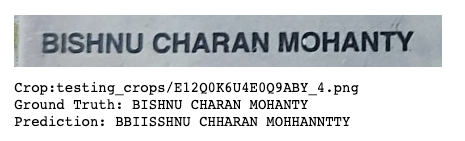




2. Calculate a single probability score for each OCR prediction, which gives an estimate of the confidence of the model in its prediction. Along with the confidence value, a reasonable conf threshold should also be chosen to optimize for high precision and recall.


3. Write an algorithm to predict each character’s region within a single crop, and mask a part of the text image.

For eg, masking ‘CHARAN’ in the following image using character regions

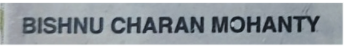

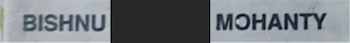



Along with the code, you will find some sample text crops that can be used for testing.

  - Each image has a corresponding `.txt` file and `.pkl` file. The text file contains the ground truth for the image where as the Pickle file contains the softmax values of the CRNN model.


### The below cell consists of code that is required to initiate and setup the assignment for you. Please run it before you move ahead.

In [1]:
# Initiation code.

# Required Imports
from collections import OrderedDict
from IPython.display import Image, display
import os
import cv2
import numpy as np
import pickle



In [2]:
#HELPER FUNCTIONS.

# Charset consists of 74 characters + NULL (which is the 75th character)
CHARSET = 'ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789 /-,.:<&()#;'

'''
get_softmax function takes in image name
returns image and CRNN softmax values for each timestep for the image.
Hint: Get a clear understanding of timestep concept in CRNN
'''
def get_softmax(image_name):

    img = cv2.imread(image_name)
    gt = open(image_name + '.txt').readlines()[0]
    softmax = pickle.load(open(image_name+".pkl", "rb"))
    return img, gt, softmax

"""
process function takes in softmax value.
Returns predicted output_text, single confidence score for the image's prediction, character regions
1. Make all changes here to output correct probabilities and regions.
2. Because of the timestep concept, character repetitions can occur (check predictions).
    Make necessary modifications to fix this.
"""
def process(softmax):

    seq_len = softmax.shape[0]

    decoded = np.argmax(softmax, axis = 1)

    output_text = []
    output_prob = 1.0
    output_text_regions = []

    for i in range(seq_len):
        # Last character is a NULL token (Last node in softmax layer)
        if decoded[i] != len(CHARSET):
            output_text.append(CHARSET[decoded[i]])

    output_text = ''.join(output_text)

    return output_text, output_prob, output_text_regions

"""
    Input to CRNN is always of height 32px while the width might vary.
    Any input of width Y will have Y/4 timesteps in the sequence.
    Thus, an input of shape Y x 32 will be divided into Y/4 timesteps, each of shape 4 x 32
"""
def width_to_seq_len(width, epsilon=0.0001):
    return int(width / (4 + epsilon))

"""
Preprocess function that was used to process images before feedforwarding through the CRNN net
"""
def preProcessImages(images_test):
    if len(images_test) == 0:
        return []

    images_out = []
    for i in range(len(images_test)):
        img = 1.0 * cv2.cvtColor(images_test[i], cv2.COLOR_BGR2GRAY) / 255.0

        resize_factor = 1.0 * 32 / img.shape[0]
        out_width = int(img.shape[1] * resize_factor)

        # Minimum length required for processing
        if out_width < 41:
            out_width = 41

        img = cv2.resize(img, (out_width, 32))
        images_out.append(img)

    return images_out

def calculate_metrics(gt, output, conf):
    """Calculate metrics for all prediction."""

    # Instructions for Matching Ground Truth (gt) with Predicted Outputs (output) using Confidence Scores (conf):

    # - gt: List of ground truth words, e.g., gt = ['hello', 'world']
    # - output: List of predicted words, e.g., output = ['hllo', 'world']
    # - conf: List of confidence scores for each prediction, e.g., conf = [0.9, 0.9]


    conf_threshold = 0 # SET CONFIDENCE THRESHOLD HERE
    precision = 0
    recall = 0
    accuracy = 0

    #True Positives -> gt is equal to output and confidence is above threshold
    #False Positives -> gt is not equal to output and confidence is above threshold
    #True Negatives -> gt is not equal to output and confidence is below threshold
    #False Negatives -> gt is equal to output and confidence is below threshold

    """write code here to measure the precision, recall, and accuracy of the predictions"""


    return precision, recall, accuracy

### The following cell will help you visualize the input image, ground truth and prediction of the CRNN model for the respective image.

566


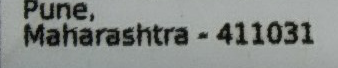

Crop: 02LG1LOETLZTUU9N_10.png
Ground Truth: Maharashtra - 411031
Prediction: Maharashttra - 411031


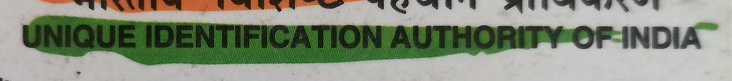

Crop: 02SCI7TGBB8R2KV7_1.png
Ground Truth: UNIQUE IDENTIFICATION AUTHORITY OF INDIA
Prediction: UNIIQUE  IDDENTTIFIICATTIONN AAUUTTHHORIITTY OOF  INDIA


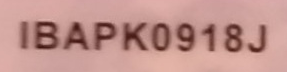

Crop: 050TN14UKIIH8YBD_4.png
Ground Truth: IBAPK0918J
Prediction: IBAPK0918J


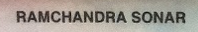

Crop: 05ZXR2UZ18SZR7E5_3.png
Ground Truth: RAMCHANDRA SONAR
Prediction: RAMCHHANDRRA SONAR


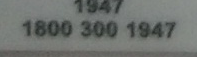

Crop: 09CDR6OPN2VMLP7P_19.png
Ground Truth: 1800 300 1947
Prediction: 1800  300 1947


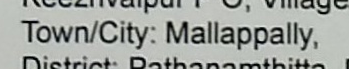

Crop: 09WEHLJPO25V57TD_11.png
Ground Truth: Town/City: Mallappally,
Prediction: Town/CCity:  Mallappall),


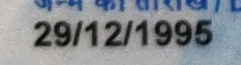

Crop: 0AZRYZIU3IXFFKLN_14.png
Ground Truth: 29/12/1995
Prediction: 29/12/1995


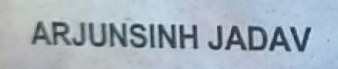

Crop: 0BQ5XVZFYVCEUNDN_4.png
Ground Truth: ARJUNSINH JADAV
Prediction: ARJUNSINH  JADAV


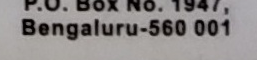

Crop: 0DPCGBUT8R5DI6NZ_22.png
Ground Truth: Bengaluru-560 001
Prediction: Bennggalluruu-5560 001


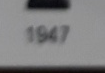

Crop: 0FR1KSAZKK8WVCKD_12.png
Ground Truth: 1947
Prediction: 19447


In [3]:
crop_dict = OrderedDict()

#Path to testing_crops:
model_outputs_path = "./testing_crops"

# Crops and GT are stored as name.png and name.png.txt in the 'testing_crops' folder. We read these into a dictionary.
crops = [el for el in sorted(os.listdir(model_outputs_path)) if 'txt' not in el and 'pkl' not in el]
print(len(crops))


# Displaying the details of the first 10 samples
for idx in range(10):
    display(Image(filename = model_outputs_path + "/" + crops[idx]))
    print('Crop: ' + crops[idx])                        # Crop name

    img, gt, softmax = get_softmax(model_outputs_path + "/" + crops[idx])
    print('Ground Truth: ' + gt)                        # Ground truth

    outputs, confs, char_regions = process(softmax)
    print('Prediction: ' + outputs)                     # Predicted output



> Task 1 - Ensure the OCR output does not have any duplicate character predictions

My Notes:-

- why does duplicate character prediction happen in first place ?
  
  The reason that duplicacy happens is because the model predicts character at every timestep and one character can span multiple timesteps, hence duplicacy is present

- what is a timestep ?
 
  each timestep is one position along the width of the input image

- Let's say base image is of shape (1, 1, 32, 128) the cnn pipeline may output (1, 512, 1, 32)
  - where 512 is the resilt of convolution filters, hence we get 512 feature maps
  - height becomes 1 as cnn will compress vertical structure into learned 512 feature vectors
    - reason we want height to be 1 is because we want it to be sequential for input to rnn. for  horizontal text the sequence flows from left to right and hence we preserve that
  - 32 is final number of timesteps  


566


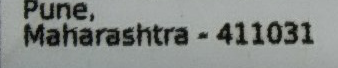

Crop: 02LG1LOETLZTUU9N_10.png
Ground Truth: Maharashtra - 411031
Prediction: Maharashtra - 411031


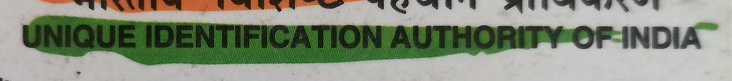

Crop: 02SCI7TGBB8R2KV7_1.png
Ground Truth: UNIQUE IDENTIFICATION AUTHORITY OF INDIA
Prediction: UNIQUE IDENTIFICATION AUTHORITY OF INDIA


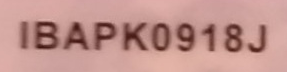

Crop: 050TN14UKIIH8YBD_4.png
Ground Truth: IBAPK0918J
Prediction: IBAPK0918J


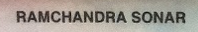

Crop: 05ZXR2UZ18SZR7E5_3.png
Ground Truth: RAMCHANDRA SONAR
Prediction: RAMCHANDRA SONAR


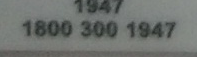

Crop: 09CDR6OPN2VMLP7P_19.png
Ground Truth: 1800 300 1947
Prediction: 1800 300 1947


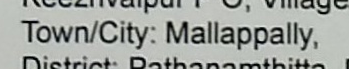

Crop: 09WEHLJPO25V57TD_11.png
Ground Truth: Town/City: Mallappally,
Prediction: Town/City: Mallappall),


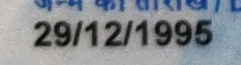

Crop: 0AZRYZIU3IXFFKLN_14.png
Ground Truth: 29/12/1995
Prediction: 29/12/1995


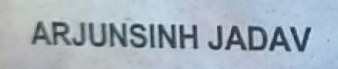

Crop: 0BQ5XVZFYVCEUNDN_4.png
Ground Truth: ARJUNSINH JADAV
Prediction: ARJUNSINH JADAV


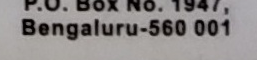

Crop: 0DPCGBUT8R5DI6NZ_22.png
Ground Truth: Bengaluru-560 001
Prediction: Bengaluru-560 001


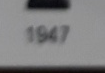

Crop: 0FR1KSAZKK8WVCKD_12.png
Ground Truth: 1947
Prediction: 1947


In [5]:
## solution for task 1 here -

def decode_text(softmax):
    blank_idx = len(CHARSET)

    decoded = np.argmax(softmax, axis=1)

    output_text = []
    prev_char = None

    for curr_char in decoded:
        if curr_char == prev_char:
            continue

        if curr_char != blank_idx:
            output_text.append(CHARSET[curr_char])

        prev_char = curr_char

    return ''.join(output_text)


def process(softmax):
    output_text = decode_text(softmax)
    return output_text, 1.0, []


## lets run the updated process fn now

crop_dict = OrderedDict()
model_outputs_path = "./testing_crops"
crops = [el for el in sorted(os.listdir(model_outputs_path)) if 'txt' not in el and 'pkl' not in el]
print(len(crops))

for idx in range(10):
    display(Image(filename = model_outputs_path + "/" + crops[idx]))
    print('Crop: ' + crops[idx])                        

    img, gt, softmax = get_softmax(model_outputs_path + "/" + crops[idx])
    print('Ground Truth: ' + gt)                        

    outputs, confs, char_regions = process(softmax)
    print('Prediction: ' + outputs)                     





> Task 2 - Calculate a single probability score for each OCR prediction, which gives an estimate of the confidence of the model in its prediction. Along with the confidence value, a reasonable conf threshold should also be chosen to optimize for high precision and recall


My Notes:-

- since one character prediction can span multiple timesteos, we need to condense the probability scores of every timestep prediction as one for that particular same character and then finally on basis of the grouped prediction we need to output word prediction probability. best way would be to penalize low confidence chars more and get an accurate enough confidence for the overall prediction

- need to implement metric calculation fn and find out the best possible threshold
    - can be done via f1 score as it balances both precision and recall




In [ ]:
## solution for task 2 here -

def decode_with_confidence(softmax):
    blank_idx = len(CHARSET)

    decoded = np.argmax(softmax, axis=1)
    max_probs = np.max(softmax, axis=1)

    output_text = []
    char_probs = []

    i = 0

    while i < len(decoded):
        curr_char = decoded[i]
        probs = []

        while i < len(decoded) and decoded[i] == curr_char:
            probs.append(max_probs[i])
            i += 1

        if curr_char != blank_idx:
            output_text.append(CHARSET[curr_char])
            # average probability across its repeated timesteps
            char_probs.append(float(np.mean(probs)))

    output_text = ''.join(output_text)

    # Word level confidence  geometric mean of character confidences
    if char_probs:
        char_probs = np.array(char_probs)
        output_prob = float(np.exp(np.mean(np.log(char_probs))))
        
    else:
        output_prob = 0.0

    return output_text, output_prob


def process(softmax):
    output_text, output_prob = decode_with_confidence(softmax)
    return output_text, output_prob, []


def calculate_metrics(gt_list, output_list, conf_list, conf_threshold):
    tp = fp = tn = fn = 0

    for gt, pred, conf in zip(gt_list, output_list, conf_list):
        is_correct = (gt == pred)
        is_confident = (conf >= conf_threshold)

        if is_correct and is_confident:
            tp += 1
        elif not is_correct and is_confident:
            fp += 1
        elif not is_correct and not is_confident:
            tn += 1
        else:
            fn += 1

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    accuracy = (tp + tn) / len(gt_list) if len(gt_list) else 0

    return precision, recall, accuracy


gt_list = []
output_list = []
conf_list = []

for crop in crops:
    img, gt, softmax = get_softmax(model_outputs_path + "/" + crop)

    output_text, output_prob, _ = process(softmax)

    gt_list.append(gt)
    output_list.append(output_text)
    conf_list.append(output_prob)


best_threshold = 0.0
best_f1 = 0.0

for threshold in np.arange(0.0, 1.01, 0.05):
    precision, recall, accuracy = calculate_metrics(gt_list, output_list, conf_list, threshold)

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0
    )

    print(
        "threshold:", round(threshold, 2),
        "precision:", round(precision, 3),
        "recall:", round(recall, 3),
        "accuracy:", round(accuracy, 3),
        "f1:", round(f1, 3)
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)


threshold: 0.0 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.05 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.1 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.15 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.2 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.25 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.3 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.35 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.4 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.45 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.5 precision: 0.696 recall: 1.0 accuracy: 0.696 f1: 0.821
threshold: 0.55 precision: 0.697 recall: 1.0 accuracy: 0.698 f1: 0.822
threshold: 0.6 precision: 0.704 recall: 1.0 accuracy: 0.707 f1: 0.826
threshold: 0.65 precision: 0.707 recall: 1.0 accuracy: 0.712 f1: 0.829
threshold: 0.


> Task 3 - Write an algorithm to predict each character’s region within a single crop, and mask a part of the text image

My Notes:-

- Goal here is to mask characters region using the target text present in the decoded OCR output, for this we will need characters starting and ending timestep then we can check pixel per timestep by first using the preprocessing fn and obtaining the width from there and then we can divide that width by the timesteps that we have which will give us pixels occupied per timestep and thenn calculate pixel coordinates and mask the image's portion. For simplicity i am assuming that we have 1 targeted text in sequence, if not then solution can be extended to find all occurrences and return/mask a list of corresponding regions


Prediction: ARJUNSINH JADAV
Character timestep regions: [(4, 4), (6, 6), (8, 8), (10, 10), (12, 12), (15, 15), (16, 16), (18, 18), (21, 21), (22, 23), (24, 24), (26, 26), (29, 29), (31, 31), (34, 34)]
Masked text: JADAV
Masked char range: (10, 14)
Masked pixel region: (98, 143)


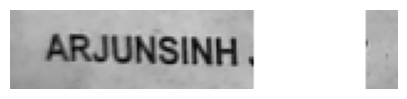

In [27]:
## solution for bonus here

import matplotlib.pyplot as plt

def decode_with_confidence_and_regions(softmax):
    blank_idx = len(CHARSET)

    decoded = np.argmax(softmax, axis=1)
    max_probs = np.max(softmax, axis=1)

    output_text = []
    char_probs = []
    char_regions = []

    i = 0

    while i < len(decoded):
        curr_char = decoded[i]
        start = i
        probs = []

        while i < len(decoded) and decoded[i] == curr_char:
            probs.append(max_probs[i])
            i += 1

        end = i - 1

        if curr_char != blank_idx:
            output_text.append(CHARSET[curr_char])
            char_probs.append(float(np.mean(probs)))
            char_regions.append((start, end))

    output_text = ''.join(output_text)

    if char_probs:
        char_probs = np.array(char_probs)
        output_prob = float(np.exp(np.mean(np.log(char_probs))))
    else:
        output_prob = 0.0

    return output_text, output_prob, char_regions


def process(softmax):
    return decode_with_confidence_and_regions(softmax)


def mask_substring_region(img, softmax, output_text, char_regions, target_text):

    start_char_idx = output_text.find(target_text)

    if start_char_idx == -1:
        raise ValueError(f"Target text '{target_text}' not found in prediction '{output_text}'")

    end_char_idx = start_char_idx + len(target_text) - 1

    if end_char_idx >= len(char_regions):
        raise ValueError(
            f"Target range {start_char_idx}-{end_char_idx} is outside char_regions length {len(char_regions)}"
        )

    processed_img = preProcessImages([img])[0]

    processed_width = processed_img.shape[1]
    seq_len = softmax.shape[0]

    pixel_per_timestep = processed_width / seq_len

    start_timestep = char_regions[start_char_idx][0]
    end_timestep = char_regions[end_char_idx][1]

    x1 = int(start_timestep * pixel_per_timestep)
    x2 = int((end_timestep + 1) * pixel_per_timestep)

    masked_img = processed_img.copy()

    # Mask selected substring region
    masked_img[:, x1:x2] = 1.0

    return masked_img, (x1, x2), (start_char_idx, end_char_idx)


####### example test ######

text_to_mask = "JADAV"
example_crop = "0BQ5XVZFYVCEUNDN_4.png"

img, gt, softmax = get_softmax(model_outputs_path + "/" + example_crop)
output_text, output_prob, char_regions = process(softmax)
    
print("Prediction:", output_text)
print("Character timestep regions:", char_regions)

masked_img, pixel_region, char_range = mask_substring_region(img, softmax, output_text, char_regions, text_to_mask)
print("Masked text:", text_to_mask)
print("Masked char range:", char_range)
print("Masked pixel region:", pixel_region)


plt.figure(figsize=(5, 2))
plt.imshow(masked_img, cmap="gray")
plt.axis("off")
plt.show()

